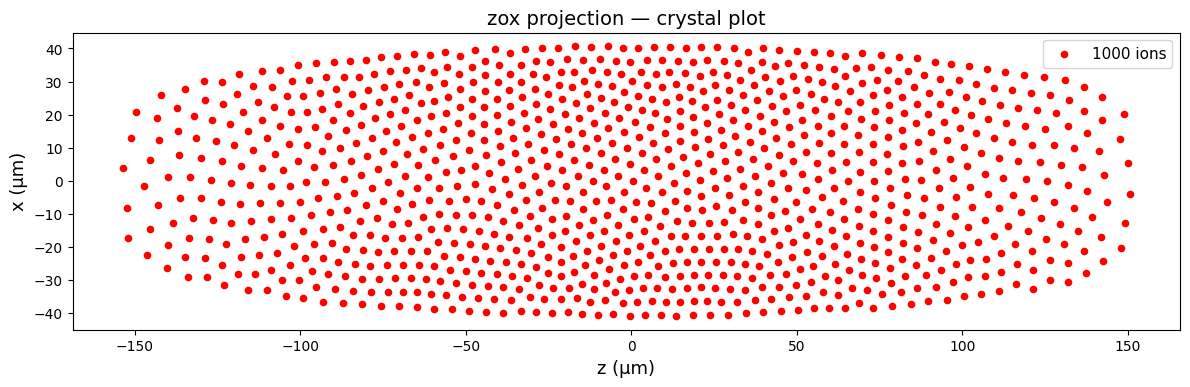

In [4]:
import numpy as np
import matplotlib.pyplot as plt

# 加载两组平衡构型
# d = np.load("../outputs/300+50Trap/npz/1000ions.npz")
d = np.load("../continuous_sampling/t039.27_interval0.08_step10/frame9999.npz")
r = d["r"] # (N, 3): x, y, z (μm)

# zox 面投影：z 为横轴，x 为纵轴
fig, ax = plt.subplots(figsize=(12, 4))
ax.scatter(r[:, 2], r[:, 0], s=20, c="red", label="1000 ions", zorder=3)
ax.set_xlabel("z (μm)", fontsize=13)
ax.set_ylabel("x (μm)", fontsize=13)
ax.set_aspect("equal")
ax.legend(fontsize=11)
ax.set_title("zox projection — crystal plot", fontsize=14)
plt.tight_layout()
plt.show()


/tmp/ipykernel_2609/3302578049.py:37: UserWarning: You passed both c and facecolor/facecolors for the markers. c has precedence over facecolor/facecolors. This behavior may change in the future.
  ax.scatter(z_sim, x_sim, s=60, c="red",  marker="o", facecolors="none",


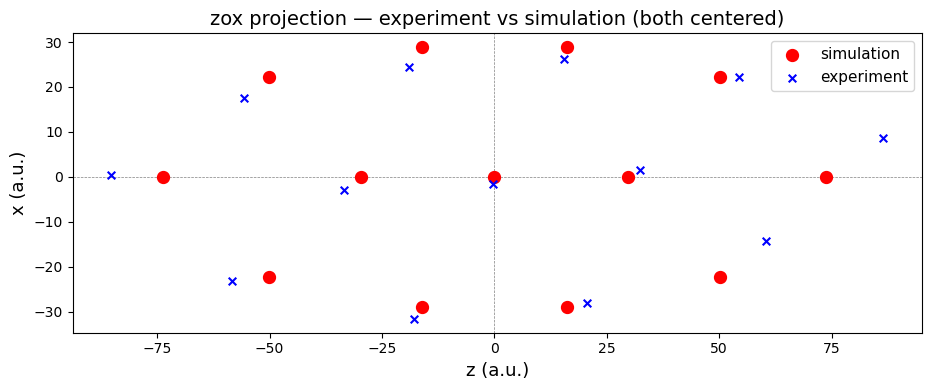

In [7]:
# from analysis.crystal_compare import experiment_crystal
import numpy as np
import matplotlib.pyplot as plt

# 实验晶格数据：第 1 列为 x，第 2 列为 z
experiment_crystal = np.array([[ 38.47095628, 340.67368343],
 [ 14.8254245,  367.48612259],
 [ 55.59091618, 370.1924113 ],
 [ 35.12156873, 392.39767451],
 [ 62.4120447,  406.95861191],
 [  6.3098248,  408.02784506],
 [ 36.39642191, 425.62437908],
 [ 64.14040325, 441.47677375],
 [  9.8646638,  446.59222237],
 [ 39.49194443, 458.37457508],
 [ 60.26615231, 480.19486677],
 [ 23.62029039, 486.32171873],
 [ 46.67899703, 512.36846012]])


# 平移到以晶格中心（所有离子坐标平均值）为原点
xc, zc = experiment_crystal.mean(axis=0)  # (mean_x, mean_z)
x_exp = experiment_crystal[:, 0] - xc
z_exp = experiment_crystal[:, 1] - zc

# 加载模拟晶格（同样平移到以晶格中心为原点）
d = np.load("../outputs/IdeaFreq/fx208fy917fz130.npz")
r = d["r"]*4  # (N, 3): x, y, z (μm)
# d = np.load("/home/ylcyyds/Crystal configuration/data_cache/13ions_Ba135_freq_0.322_1.355_0.222/pos_data/10.npy")
# r = d*3
cx, cy, cz = r.mean(axis=0)
x_sim = r[:, 0] - cx
z_sim = r[:, 2] - cz

# zox 面投影：z 为横轴，x 为纵轴
fig, ax = plt.subplots(figsize=(12, 4))
ax.scatter(z_sim, x_sim, s=60, c="red",  marker="o", facecolors="none",
           linewidths=1.8, label="simulation", zorder=3)
ax.scatter(z_exp, x_exp, s=30, c="blue", marker="x",
           label="experiment", zorder=4)
ax.axhline(0, color="gray", lw=0.5, ls="--", zorder=1)
ax.axvline(0, color="gray", lw=0.5, ls="--", zorder=1)
ax.set_xlabel("z (a.u.)", fontsize=13)
ax.set_ylabel("x (a.u.)", fontsize=13)
ax.set_aspect("equal")
ax.legend(fontsize=11)
ax.set_title("zox projection — experiment vs simulation (both centered)", fontsize=14)
plt.tight_layout()
plt.show()
